**Bayesian analysis** is a powerful framework in machine learning that allows us to incorporate prior knowledge and update our beliefs as new data becomes available. In this tutorial, we'll walk through the steps of performing Bayesian analysis using your own dataset, simulating data, setting up the dataset (e.g., QQ plots), and analyzing posterior distributions.

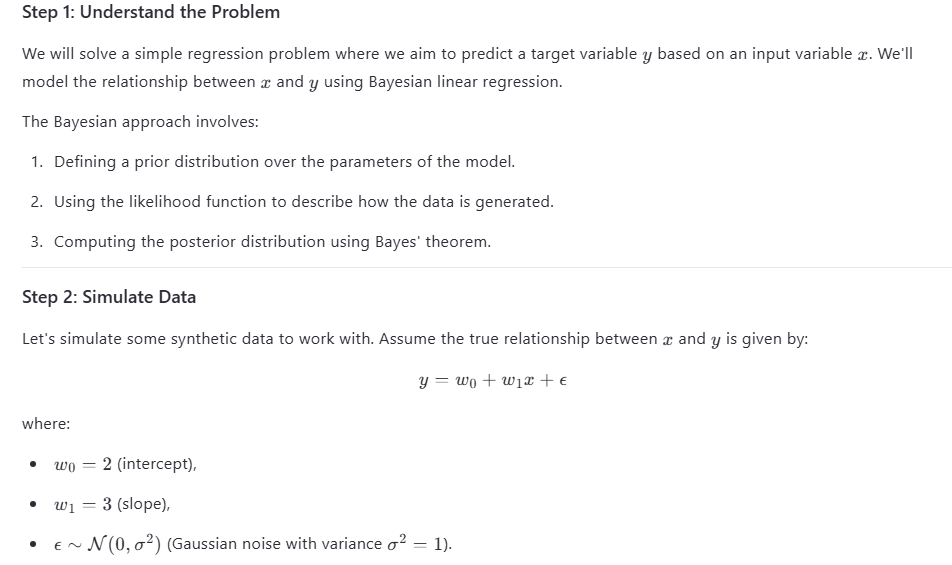

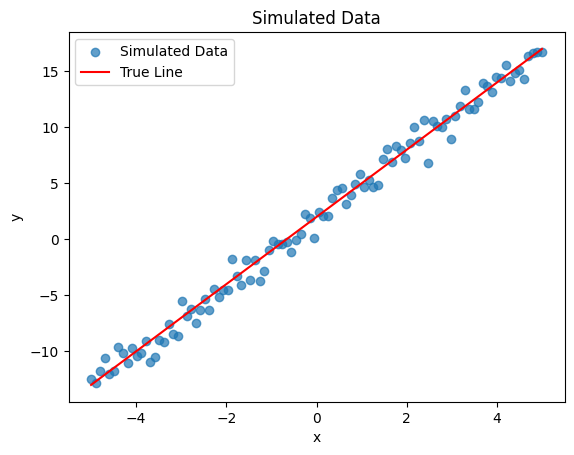

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# True parameters
w0_true = 2
w1_true = 3
sigma_noise = 1

# Generate synthetic data
np.random.seed(42)
x = np.linspace(-5, 5, 100)  # Input feature
epsilon = np.random.normal(0, sigma_noise, size=len(x))  # Noise
y = w0_true + w1_true * x + epsilon  # Target variable

# Plot the data
plt.scatter(x, y, label="Simulated Data", alpha=0.7)
plt.plot(x, w0_true + w1_true * x, color="red", label="True Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated Data")
plt.legend()
plt.show()

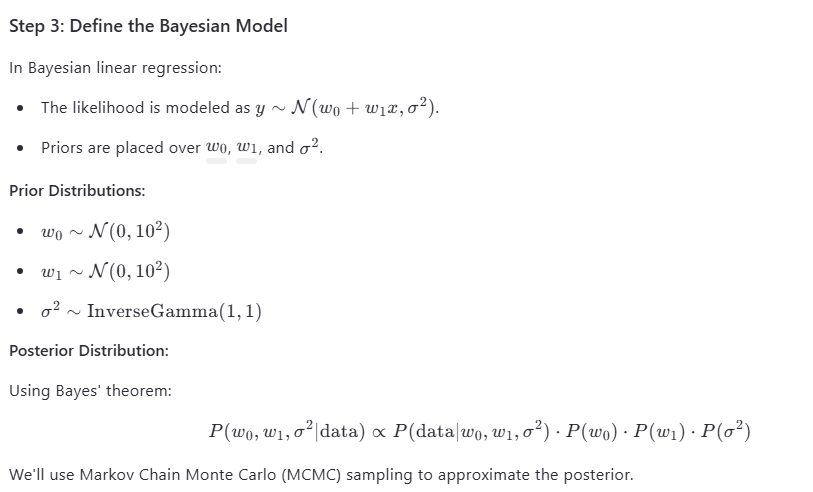

##Step 4: Implement Bayesian Analysis
We'll use pymc (a probabilistic programming library) to perform Bayesian inference.

In [2]:
pip install pymc

Output()

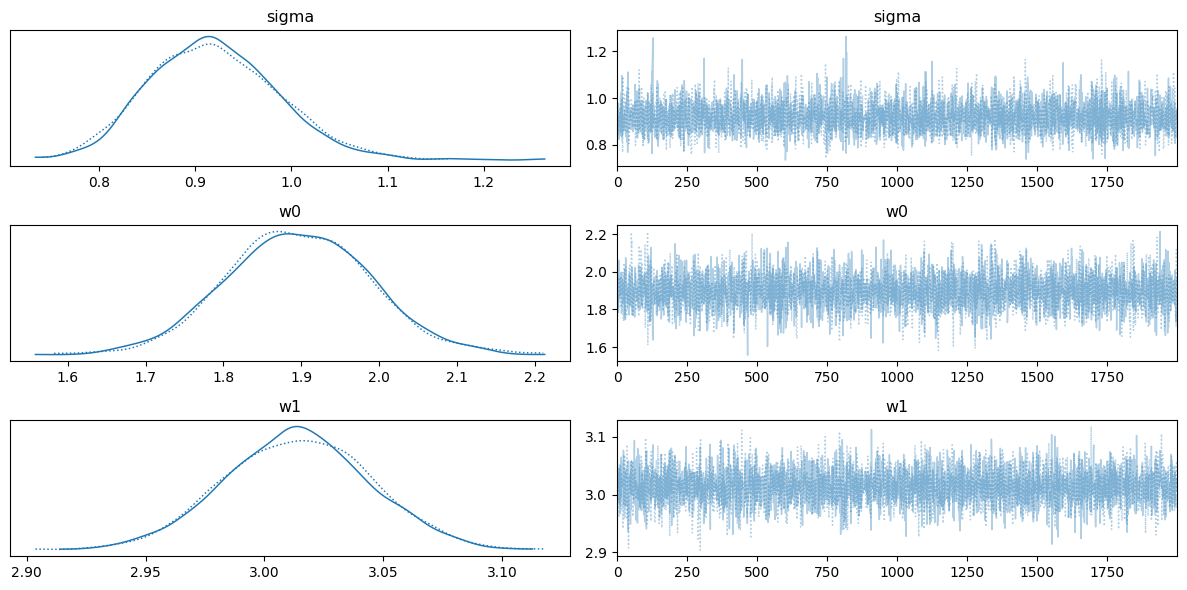

In [3]:
import pymc as pm
import arviz as az

# Define the Bayesian model
with pm.Model() as bayesian_model:
    # Priors
    w0 = pm.Normal("w0", mu=0, sigma=10)
    w1 = pm.Normal("w1", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Likelihood
    mu = w0 + w1 * x
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Perform MCMC sampling
    trace = pm.sample(2000, tune=1000, cores=2, random_seed=42)

# Visualize posterior distributions
az.plot_trace(trace)
plt.tight_layout()
plt.show()

**Step 5: Analyze the Posterior**
After running the MCMC sampler, we can analyze the posterior distributions of w
0
​
 , w
1
​
 , and σ.

In [4]:
summary = az.summary(trace, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sigma  0.92  0.07    0.80     1.04        0.0      0.0   5011.07   2647.83   
w0     1.90  0.09    1.72     2.07        0.0      0.0   5398.21   3099.15   
w1     3.01  0.03    2.96     3.07        0.0      0.0   5638.98   3218.07   

       r_hat  
sigma    1.0  
w0       1.0  
w1       1.0  


Output()

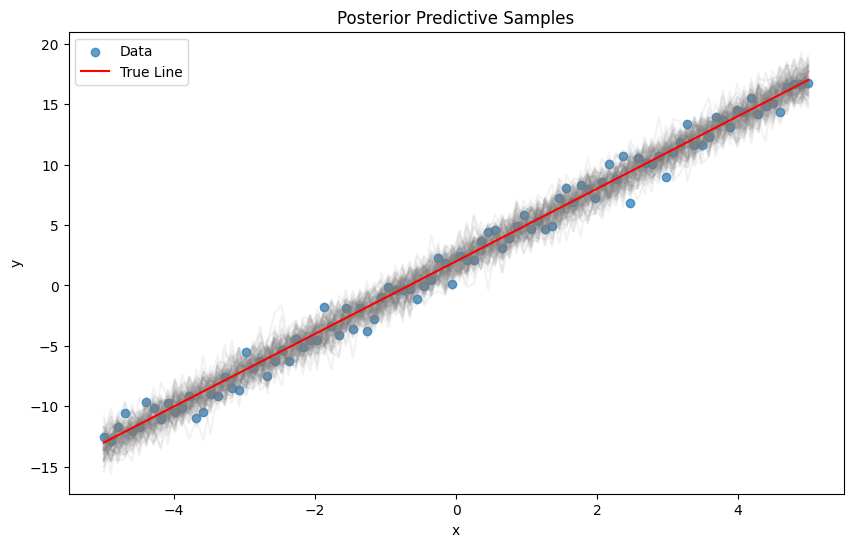

In [5]:
# Posterior predictive checks
with bayesian_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Plot posterior predictive samples
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data", alpha=0.7)
for i in range(100):
    plt.plot(x, posterior_predictive.posterior_predictive["y_obs"][0, i], color="gray", alpha=0.1)
plt.plot(x, w0_true + w1_true * x, color="red", label="True Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior Predictive Samples")
plt.legend()
plt.show()

**Step 6: Dataset Setup Activities**
QQ Plot:
A QQ plot helps assess whether the residuals follow a normal distribution.

In [ ]:
from scipy.stats import probplot

# Compute residuals
residuals = y - (trace.posterior["w0"].mean() + trace.posterior["w1"].mean() * x)

# QQ plot
plt.figure(figsize=(8, 6))
probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()